In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



DATASETS 1

In [109]:
ruta=r"C:\Users\josegutjim\Downloads\archive (1)\CarPrice_Assignment.csv"
df = pd.read_csv(ruta)

Parte 1 – Comprensión del problema

1.Identifica la variable objetivo (target) 

La variable objetivo es price (el precio del vehículo)


2.Responde: 
  ○ ¿Es un problema de clasificación o regresión? 
  ○ ¿Por qué?

-Es un problema de regresión.
-La razón está en el tipo de variable objetivo: price es una variable numérica continua, es decir, puede tomar cualquier valor dentro de un rango


3.Describe brevemente el contexto del problema

-El objetivo de negocio es estimar el precio de un vehículo a partir de sus características técnicas (tamaño y tipo de motor, potencia, peso, dimensiones, marca, tipo de combustible, entre otras). 

Parte 2 – Exploración de datos (EDA básica)

In [110]:
df.shape            # (filas, columnas)
df.head()           # primeras filas: ver cómo lucen los datos
df.info()           # tipo de dato de cada columna + conteo de no-nulos
df.isnull().sum()   # cuántos nulos hay por columna
df.describe()       # estadísticos de las columnas numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [111]:
df = df.drop(columns=["car_ID"])

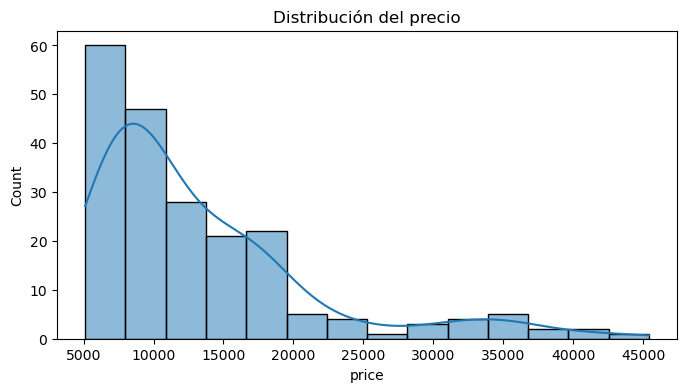

In [112]:
# Gráfico 1 — distribución del target
plt.figure(figsize=(8,4))
sns.histplot(df["price"], kde=True)
plt.title("Distribución del precio")
plt.show()

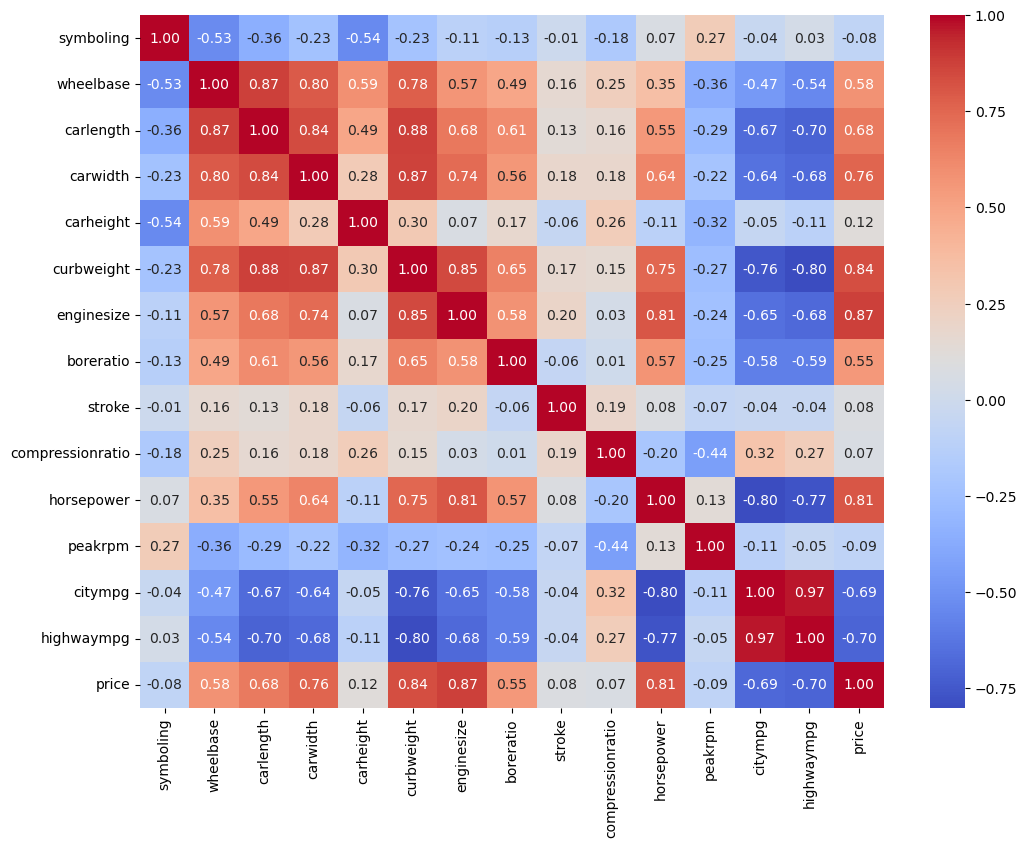

In [113]:
# Gráfico 2 — correlación entre variables numéricas
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

Parte 3 – Preparación de datos

In [114]:
df["doornumber"] = df["doornumber"].map({"two": 2, "four": 4})

In [115]:
df["cylindernumber"].unique()


array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [116]:
df["cylindernumber"] = df["cylindernumber"].map({"four": 4, "six": 6,"five": 5, "three": 3,"twelve": 12, "two": 2, "eight": 8})

In [117]:
df["brand"] = df["CarName"].str.split(" ").str[0].str.lower()
df = df.drop(columns=["CarName"])

In [118]:
df["brand"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [119]:
df["brand"] = df["brand"].replace({
    "maxda": "mazda",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
})

In [120]:
df = pd.get_dummies(df, drop_first=True)

In [121]:
X = df.drop(columns=["price"])
y = df["price"]

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Parte 4 – Modelado

In [123]:

lr = LinearRegression()          
lr.fit(X_train, y_train)         
y_pred_lr = lr.predict(X_test)   


In [124]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)          
y_pred_rf = rf.predict(X_test) 



Parte 5 – Evaluación del modelo

In [125]:
# --- Regresión Lineal ---
print("Regresión Lineal")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Regresión Lineal
MAE: 1942.067760190138
MSE: 8283565.717264859
R²: 0.8950703850024014


In [126]:
# --- Random Forest ---
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 1286.568020325203
MSE: 3331320.659548854
R²: 0.9578014823361085


Parte 6 – Interpretación

1. ¿Qué tan bueno es el modelo?
El modelo de Random Forest logró un R² el 96% de la variación en el precio de los carros. Su error promedio MAE= 1.268 es bajo teniendo en cuenta que el precio de los vehiculos esta entre 5.000 y 45.000, lo que indica predicciones bastante precisas. La Regresión Lineal también dio un resultado sólido (R² de 0.91), pero el Random Forest la superó en las tres métricas (MAE, MSE y R²). 
2. ¿Qué variable parece influir más en la predicción?
El tamaño del motor enginesize es la variable más influyente: es la que más se correlaciona con el precio en 0.87 , seguida del peso del vehículo curbweight, 0.84 y los caballos de fuerza horsepower, 0.81. ( Como se observa en la grafica)

3. ¿Qué mejorarías si tuvieras más tiempo?
-Aplicar logaritmo al precio antes de entrenar: la distribución está sesgada a la derecha (Gráfico 1), y esto ayudaría al modelo con los carros caros de la cola larga.
-Eliminar variables redundantes: citympg y highwaympg tienen correlación de 0.97 entre sí, o sea aportan casi la misma información.
-Conseguir más datos: 205 registros es poco; con más filas el modelo generaliza mejor.
